# Global multi-dataset fit example

We consider $N=2$ datasets sharing a common Gaussian component
with dataset-dependent amplitudes and independent linear backgrounds.

$$
y_d(x) =
A_d \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
+ m_d x + c_d
$$

The parameters $\mu$ and $\sigma$ are shared across datasets,
while $A_d$, $m_d$, and $c_d$ vary per dataset.

In [1]:
try:
    from lmfit_global import LmfitGlobal
    from lmfit_global.utils.builders import GlobalFitBuilder
except (ImportError, ModuleNotFoundError):
    import os, sys
    ROOT = os.path.abspath("..")  # parent of examples
    sys.path.insert(0, ROOT)

    from lmfit_global import LmfitGlobal
    from lmfit_global.utils.builders import GlobalFitBuilder

import numpy as np
import matplotlib.pyplot as plt

### (1) Generate synthetic multi-dataset, multi-component data

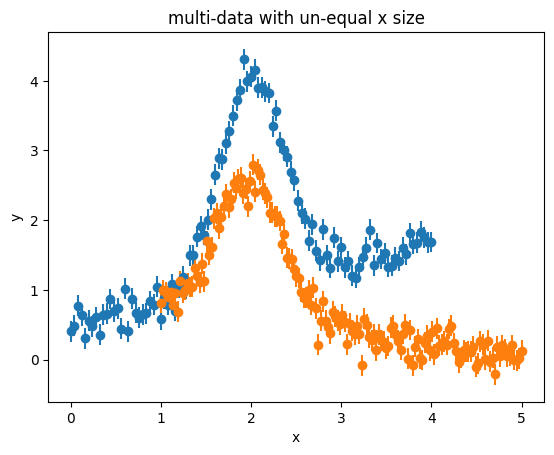

In [2]:
rng = np.random.default_rng(4)

# -------------------------
# True shared parameters
# -------------------------
mu_true = 2.0
sigma_true = 0.35

# Dataset-specific parameters
params_true = {
    0: dict(A=3.0, m=0.3, c=0.5),
    1: dict(A=2.0, m=-0.2, c=1.0),
}

# -------------------------
# Component functions
# -------------------------
def gaussian(x, amplitude, center, sigma):
    return amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))

def background(x, slope, intercept):
    return slope * x + intercept

# -------------------------
# Dataset x-grids (partially overlapping)
# -------------------------
xdat_lst = [
    np.linspace(0.0, 4.0, 101),
    np.linspace(1.0, 5.0, 150),
]

ydat_lst = []
yerr_lst = []

noise_level = 0.15

for i, x in enumerate(xdat_lst):
    p = params_true[i]

    y_gauss = gaussian(x, p["A"], mu_true, sigma_true)
    y_bg =    background(x, p["m"], p["c"])

    y = y_gauss + y_bg
    yerr = noise_level * np.ones_like(y)

    y_noisy = y + rng.normal(0, yerr)

    ydat_lst.append(y_noisy)
    yerr_lst.append(yerr)

    plt.errorbar(x, y_noisy, yerr=yerr, fmt='o')

plt.title("multi-data with un-equal x size")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### (2) Merge datasets onto a shared x-grid

using `utils.io_utils.merge_xyerr_data`

In [3]:
from lmfit_global.utils.io_utils import merge_xyerr_data

x, y, yerr = merge_xyerr_data(
    xdat_lst=xdat_lst,
    ydat_lst=ydat_lst,
    yerr_lst=yerr_lst,
)

print(x.shape, y.shape)


(250,) (250, 2)


### (3) Build `items` dictionary for `LmfitGlobal`

In [4]:
items_without_xy = {
    # "data": {
    #     "xy": np.column_stack([x, y]),
    # },
    "functions": {
        "theory": [
            {
                "func_name": gaussian,
                "init_params": {
                    "amplitude": dict(value=2.5, min=0),
                    "center": dict(value=1.8),
                    "sigma": dict(value=0.4, min=0.05),                    
                },
            },
            {
                "func_name": background,
                "init_params": {
                    "slope": dict(value=0.1),
                    "intercept": dict(value=0.3),                 
                },
            },
        ],
        "theory_connectors": ["+"],
    },
}

lg = LmfitGlobal(items_without_xy, log_level='info')
lg.theory_expr # or lg.pretty_expr

INFO: LmfitGlobal: Parsing inputs...
INFO: LmfitGlobal: Parsing input data...
INFO: LmfitGlobal: Parsing function models...
INFO: LmfitGlobal: 2 model component(s) detected — multi-component fit...
INFO: LmfitGlobal: Parsing function models COMPLETED...
INFO: LmfitGlobal: The model connectors used: [+]
INFO: LmfitGlobal: Parsing function(s) connectors COMPLETED...
INFO: LmfitGlobal: Building lmfit backend...
INFO: LmfitGlobal: Creating lmfit.Models for the models(s) function(s)...
INFO: LmfitGlobal: Building lmfit CompositeModel...
INFO: LmfitGlobal: CompositeModel built successfully...
INFO: LmfitGlobal: Initialized parameters...
INFO: LmfitGlobal: The model is to be constructed as...
INFO: LmfitGlobal: ########################################################################
INFO: LmfitGlobal: # y(x;) = gaussian(x, amplitude, center, sigma) + background(x, slope, #
INFO: LmfitGlobal: # intercept)                                                           #
INFO: LmfitGlobal: ##########

### (4) `items: WARNINGS` set data as `.set_data(x, y)`

In [5]:
lg.set_data(x, y)

INFO: LmfitGlobal: Data set via set_data(): N=250, ny=2
INFO: LmfitGlobal: Parsing input data...
INFO: LmfitGlobal: Detected 2 dataset(s) with N=250 points each
INFO: LmfitGlobal: XRANGE applied: [0.0, 5.0] → N=250 points per dataset
INFO: LmfitGlobal: Parsing input data COMPLETED...
INFO: LmfitGlobal: Building lmfit backend...
INFO: LmfitGlobal: Creating lmfit.Models for the models(s) function(s)...
INFO: LmfitGlobal: Building lmfit CompositeModel...
INFO: LmfitGlobal: CompositeModel built successfully...
INFO: LmfitGlobal: Initialized parameters...


### (4)* `items: WARNINGS` 2 set nan policy `.set_nan_policy("omit")`

In [6]:
lg.set_nan_policy("omit")

INFO: LmfitGlobal: Updating nan_policy: 'raise' -> 'omit'
INFO: LmfitGlobal: Building lmfit backend...
INFO: LmfitGlobal: Creating lmfit.Models for the models(s) function(s)...
INFO: LmfitGlobal: Building lmfit CompositeModel...
INFO: LmfitGlobal: CompositeModel built successfully...
INFO: LmfitGlobal: Initialized parameters...


### (5) pretty print initial parameters

shared global parameters:

```bash
c0_center_0 = c0_center_1
c0_sigma_0 =  c0_sigma_1
```

In [7]:
def link_global(lg, names):
    lg.set_global(names, overwrite_expr=True)

ny = 2 # number of datasets
link_global(lg, [f"c0_center_{i}" for i in range(ny)])
link_global(lg, [f"c0_sigma_{i}" for i in range(ny)])

lg.init_params.pretty_print()

INFO: LmfitGlobal: SHARED parameters: 'c0_center_0' & 'c0_center_1' to reference='c0_center_0' ...
INFO: LmfitGlobal: SHARED parameters: 'c0_sigma_0' & 'c0_sigma_1' to reference='c0_sigma_0' ...


Name               Value      Min      Max   Stderr     Vary     Expr Brute_Step
c0_amplitude_0       2.5        0      inf     None     True     None     None
c0_amplitude_1       2.5        0      inf     None     True     None     None
c0_center_0          1.8     -inf      inf     None     True     None     None
c0_center_1          1.8     -inf      inf     None    False c0_center_0     None
c0_sigma_0           0.4     0.05      inf     None     True     None     None
c0_sigma_1           0.4     0.05      inf     None    False c0_sigma_0     None
c1_intercept_0       0.3     -inf      inf     None     True     None     None
c1_intercept_1       0.3     -inf      inf     None     True     None     None
c1_slope_0           0.1     -inf      inf     None     True     None     None
c1_slope_1           0.1     -inf      inf     None     True     None     None


### (6) fit, report and plot ...

In [8]:
lg.fit(nan_policy="omit")  # or use nan_policy="omit" in fit()
result = lg.result # result Minimizer

INFO: LmfitGlobal: Fitting started (fit_method='leastsq') ...
INFO: LmfitGlobal: Fitting finished: SUCCESS
INFO: LmfitGlobal: nfev=55 | rsquared=0.97442878 | redchi=0.022632291 | aic=-943.01304 | bic=-914.80942 | time=0.03s ...


In [9]:
lg.report()

[[Model]]
    (Model(gaussian, prefix='c0_') + Model(background, prefix='c1_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 55
    # data points      = 251
    # variables        = 8
    chi-square         = 5.49964668
    reduced chi-square = 0.02263229
    Akaike info crit   = -943.013041
    Bayesian info crit = -914.809418
    R-squared          = 0.97442878
[[Variables]]
    c0_amplitude_0:  3.00996231 +/- 0.04783805 (1.59%) (init = 2.5)
    c0_center_0:     1.99860448 +/- 0.00511861 (0.26%) (init = 1.8)
    c0_sigma_0:      0.35543521 +/- 0.00611213 (1.72%) (init = 0.4)
    c1_slope_0:      0.30188838 +/- 0.01307713 (4.33%) (init = 0.1)
    c1_intercept_0:  0.47437326 +/- 0.03295064 (6.95%) (init = 0.3)
    c0_amplitude_1:  1.98649994 +/- 0.04617283 (2.32%) (init = 2.5)
    c0_center_1:     1.99860448 +/- 0.00511861 (0.26%) == 'c0_center_0'
    c0_sigma_1:      0.35543521 +/- 0.00611213 (1.72%) == 'c0_sigma_0'
    c1_slope_1:     -0.20363052 +/- 0

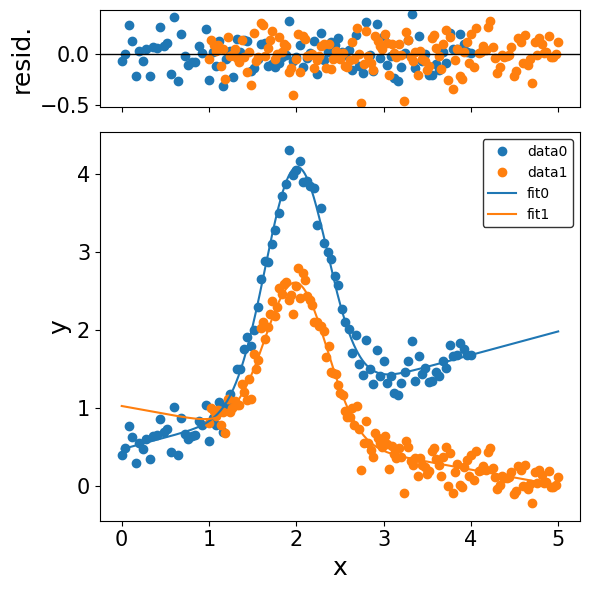

In [10]:
pretty_kw={'width': 6, 'height':6, 'dpi':100} # width and height and dpi of figure, or None to use default settings

# lg.plot()
lg.plot(numpoints=1024, xlabel='x', ylabel='y', pretty_kw=pretty_kw)
plt.show()

### (7) Extract structured results with `FitData`

In [11]:
fitdata = lg.get_fitdata(numpoints=600)

print("Number of Datasets:", fitdata.n_datasets)
print("Components Names:", fitdata.component_names)

Number of Datasets: 2
Components Names: ['c0', 'c1']


### (8) Plot components per dataset (multi-panel)

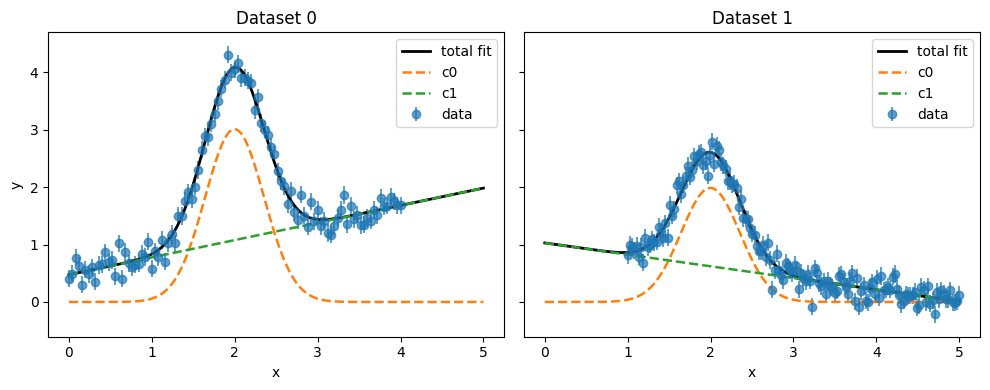

In [12]:
n = fitdata.n_datasets
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)

if n == 1:
    axes = [axes]

for dset, ax in enumerate(axes):
    ax.errorbar(
        fitdata.x_data,
        fitdata.y_data[:, dset],
        yerr=yerr[:, dset],
        fmt="o",
        label="data",
        alpha=0.7,
    )

    ax.plot(
        fitdata.x_model,
        fitdata.y_fit[:, dset],
        "k-",
        lw=2,
        label="total fit",
    )

    for cname, comp in fitdata.components[dset].items():
        ax.plot(
            fitdata.x_model,
            comp["model"],
            "--",
            lw=1.8,
            label=cname,
        )

    ax.set_title(f"Dataset {dset}")
    ax.set_xlabel("x")
    ax.legend()

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()


### (9) (Optional) Uncertainty bands

In [13]:
lg.eval_uncertainty(sigma=3)

dely = lg.dely
dely_comps = lg.dely_comps

### (10) (Optional) Exports

In [14]:
lg.export("params")
## OR WITH ###
# lg.to_dataframe()

,value,stderr,vary,min,max,expr
c0_amplitude_0,3.009962,0.047838,True,0.00,inf,None
c0_center_0,1.998604,0.005119,True,-inf,inf,None
c0_sigma_0,0.355435,0.006112,True,0.05,inf,None
c1_slope_0,0.301888,0.013077,True,-inf,inf,None
c1_intercept_0,0.474373,0.032951,True,-inf,inf,None
c0_amplitude_1,1.986500,0.046173,True,0.00,inf,None
c0_center_1,1.998604,0.005119,False,-inf,inf,c0_center_0
c0_sigma_1,0.355435,0.006112,False,0.05,inf,c0_sigma_0
c1_slope_1,-0.203631,0.014403,True,-inf,inf,None
c1_intercept_1,1.028607,0.054129,True,-inf,inf,None


In [15]:
res_dict = lg.export("dict")
## OR WITH ###
# res_dict = lg.to_dict()
# res_dict

In [16]:
df = lg.export("data")  
df = lg.export("data", fitdata_kws={"numpoints": 1024})
## OR WITH ###
# df = lg.data_to_dataframe()
# df = lg.data_to_dataframe(fitdata_kws={"numpoints": 1024})
df

,xdat,xfit,ydat0,yfit0,resid0,ydat1,yfit1,resid1
0,0.00,0.000000,0.402232,0.474374,-0.072142,NaN,1.028607,NaN
1,0.04,0.004888,0.485793,0.475849,-0.000657,NaN,1.027612,NaN
2,0.08,0.009775,0.773559,0.477325,0.275034,NaN,1.026617,NaN
3,0.12,0.014663,0.634874,0.478800,0.124271,NaN,1.025622,NaN
4,0.16,0.019550,0.301793,0.480276,-0.220887,NaN,1.024627,NaN
...,...,...,...,...,...,...,...,...
1019,NaN,4.980450,NaN,1.977913,NaN,NaN,0.014436,NaN
1020,NaN,4.985337,NaN,1.979389,NaN,NaN,0.013440,NaN
1021,NaN,4.990225,NaN,1.980864,NaN,NaN,0.012445,NaN
1022,NaN,4.995112,NaN,1.982340,NaN,NaN,0.011450,NaN


In [17]:
res_json = lg.export("json", indent=2)
## OR WITH ###
# res_json = lg.to_json()
# res_json

In [18]:
x_data, x_fit, y_data, y_fit, resid = lg.export("numpy")
x_data, x_fit, y_data, y_fit, resid = lg.export("numpy", fitdata_kws={"numpoints": 1024})
## OR WITH ###
# x_data, x_fit, y_data, y_fit, resid = lg.to_numpy()
# x_data, x_fit, y_data, y_fit, resid = lg.to_numpy(fitdata_kws={"numpoints": 1024})
# resid